In [8]:
# Cell 1: Install all required packages
%pip install "transformers[torch]" datasets evaluate kaggle tqdm scikit-learn matplotlib seaborn python-dotenv 

print("✅ All libraries installed successfully.")


  Using cached datasets-4.3.0-py3-none-any.whl.metadata (18 kB)
  Using cached evaluate-0.4.6-py3-none-any.whl.metadata (9.5 kB)
  Using cached kaggle-1.7.4.5-py3-none-any.whl.metadata (16 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached python_dotenv-1.2.1-py3-none-any.whl.metadata (25 kB)
  Using cached transformers-4.57.1-py3-none-any.whl.metadata (43 kB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
  Using cached numpy-2.3.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached regex-2025.10.23-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x8

In [9]:
# Cell 2: Load environment variables and authenticate
import os
from dotenv import load_dotenv
from huggingface_hub import login

# Load the .env file
load_dotenv()

# --- Authenticate with Hugging Face ---
HF_TOKEN = os.getenv('HF_TOKEN')
if HF_TOKEN:
    login(token=HF_TOKEN)
    print("Hugging Face login successful.")
else:
    print("HF_TOKEN not found in .env file. Gated datasets may be inaccessible.")

# --- Configure Kaggle API ---
# Sets the environment variable to the current directory where kaggle.json is located
os.environ['KAGGLE_CONFIG_DIR'] = '.'
print("Kaggle API configured to use kaggle.json from the current directory.")


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Hugging Face login successful.
Kaggle API configured to use kaggle.json from the current directory.


In [10]:
# Cell 3: Download all datasets
import subprocess

# Define the path for your data
DATA_PATH = 'data'
os.makedirs(DATA_PATH, exist_ok=True)

# --- Download from Kaggle ---
print("Downloading Kaggle datasets...")
# Dataset 1: The collection of parsed files
!kaggle datasets download -d andrewmvd/cyberbullying-classification -p "{DATA_PATH}" --unzip --quiet
# Dataset 2: The single cyberbullying tweets file
!kaggle datasets download -d saurabhshahane/cyberbullying-dataset -p "{DATA_PATH}" --unzip --quiet
print("Kaggle datasets downloaded.")

# --- Download from Hugging Face ---
print("\nDownloading Hugging Face dataset...")
from datasets import load_dataset
hf_dataset = load_dataset('cike-dev/cyberbullying_dataset')
hf_csv_path = os.path.join(DATA_PATH, 'dataset_huggingface.csv')
hf_dataset['train'].to_csv(hf_csv_path, index=False)
print(f"Hugging Face dataset saved to: {hf_csv_path}")

print("\n✅ All datasets downloaded.")


Dataset URL: https://www.kaggle.com/datasets/andrewmvd/cyberbullying-classification
License(s): Attribution 4.0 International (CC BY 4.0)
Dataset URL: https://www.kaggle.com/datasets/saurabhshahane/cyberbullying-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
Kaggle datasets downloaded.



README.md:   0%|          | 0.00/3.91k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.50M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/315k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/313k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30240 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3780 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3780 [00:00<?, ? examples/s]

Creating CSV from Arrow format:   0%|          | 0/31 [00:00<?, ?ba/s]

Hugging Face dataset saved to: data/dataset_huggingface.csv

✅ All datasets downloaded.


In [11]:
# Cell 4: Combine, clean, and balance datasets
import pandas as pd
import re
from sklearn.utils import shuffle
from tqdm.notebook import tqdm

tqdm.pandas()
print("Starting data combination and preprocessing...")

# --- Load all downloaded files ---
try:
    df_tweets = pd.read_csv(os.path.join(DATA_PATH, 'cyberbullying_tweets.csv'))
    df_hf = pd.read_csv(os.path.join(DATA_PATH, 'dataset_huggingface.csv'))
    df_aggression = pd.read_csv(os.path.join(DATA_PATH, 'aggression_parsed_dataset.csv'))
    df_attack = pd.read_csv(os.path.join(DATA_PATH, 'attack_parsed_dataset.csv'))
    df_toxicity = pd.read_csv(os.path.join(DATA_PATH, 'toxicity_parsed_dataset.csv'))
    print("All source files loaded.")
except FileNotFoundError as e:
    print(f"Error loading files: {e}. Please check the file paths.")

# --- Standardize each dataframe ---
# 1. cyberbullying_tweets.csv
df_tweets.rename(columns={'tweet_text': 'text'}, inplace=True)
df_tweets['label'] = df_tweets['cyberbullying_type'].apply(lambda x: 0 if x == 'not_cyberbullying' else 1)

# 2. dataset_huggingface.csv
df_hf.rename(columns={'cleaned_text': 'text'}, inplace=True)
df_hf['label'] = df_hf['label'].apply(lambda x: 1 if x == 'bully' else 0)

# 3. Aggression, Attack, Toxicity datasets
df_aggression.rename(columns={'Text': 'text', 'oh_label': 'label'}, inplace=True)
df_attack.rename(columns={'Text': 'text', 'oh_label': 'label'}, inplace=True)
df_toxicity.rename(columns={'Text': 'text', 'oh_label': 'label'}, inplace=True)

# --- Combine into a single dataframe ---
combined_df = pd.concat([
    df_tweets[['text', 'label']],
    df_hf[['text', 'label']],
    df_aggression[['text', 'label']],
    df_attack[['text', 'label']],
    df_toxicity[['text', 'label']]
], ignore_index=True)

# --- Clean and deduplicate ---
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("\nCleaning text data (this may take a few minutes)...")
combined_df['text'] = combined_df['text'].progress_apply(clean_text)
combined_df.dropna(subset=['text'], inplace=True)
combined_df = combined_df[combined_df['text'] != '']
combined_df.drop_duplicates(subset='text', inplace=True)

# --- Balance the dataset ---
print("\nBalancing dataset...")
df_bullying = combined_df[combined_df['label'] == 1]
df_not_bullying = combined_df[combined_df['label'] == 0]
n_bullying = len(df_bullying)
df_not_bullying_undersampled = df_not_bullying.sample(n=n_bullying, random_state=42)
balanced_df = pd.concat([df_bullying, df_not_bullying_undersampled])
final_dataset = shuffle(balanced_df, random_state=42).reset_index(drop=True)

# --- Save the final dataset ---
final_dataset_path = os.path.join(DATA_PATH, 'cyberbullying_master_dataset.csv')
final_dataset.to_csv(final_dataset_path, index=False)

print(f"\n✅ Preprocessing complete. Final balanced dataset with {len(final_dataset)} samples saved to '{final_dataset_path}'")


Starting data combination and preprocessing...
All source files loaded.

Cleaning text data (this may take a few minutes)...


  0%|          | 0/469346 [00:00<?, ?it/s]


Balancing dataset...

✅ Preprocessing complete. Final balanced dataset with 136440 samples saved to 'data/cyberbullying_master_dataset.csv'


In [12]:
# Cell 5: Split data and tokenize
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import RobertaTokenizer

# --- Load the final dataset ---
DATA_PATH = 'data'
df = pd.read_csv(os.path.join(DATA_PATH, 'cyberbullying_master_dataset.csv'))

# --- Split into training and testing sets ---
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df['label'])
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)
print(f"Data split into {len(train_dataset)} training and {len(test_dataset)} testing samples.")

# --- Tokenize the datasets ---
MODEL_NAME = 'roberta-base'
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("\nTokenizing datasets...")
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format for PyTorch
tokenized_train_dataset = tokenized_train_dataset.remove_columns(["text", "__index_level_0__"]).with_format("torch")
tokenized_test_dataset = tokenized_test_dataset.remove_columns(["text", "__index_level_0__"]).with_format("torch")

print("✅ Tokenization complete.")


Data split into 122796 training and 13644 testing samples.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]


Tokenizing datasets...


Map:   0%|          | 0/122796 [00:00<?, ? examples/s]

Map:   0%|          | 0/13644 [00:00<?, ? examples/s]

✅ Tokenization complete.


In [13]:
# Cell 6: Configure and run model fine-tuning
import numpy as np
import torch
from transformers import RobertaForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

print("--- Configuring model and trainer ---")

# --- Load Model ---
model = RobertaForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# --- Define Metrics ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

# --- Define Training Arguments ---
training_args = TrainingArguments(
    output_dir='models/roberta_finetuned',
    num_train_epochs=1, # Increase to 2 or 3 for better performance
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    load_best_model_at_end=True,
    report_to="none"
)

# --- Initialize Trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
)

# --- Start Training ---
print("\n--- Starting model fine-tuning... ---")
trainer.train()
print("\n--- Fine-Tuning Complete ---")

# --- Save the Final Model ---
final_model_path = 'models/roberta_final'
trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)

print(f"\n✅ Final model and tokenizer saved to: {final_model_path}")


--- Configuring model and trainer ---


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Starting model fine-tuning... ---


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
500,0.358100,0.428941,0.878628,0.874621,0.904479,0.846673
1000,0.365300,0.371766,0.852389,0.840690,0.913058,0.778950
1500,0.342400,0.341473,0.886250,0.888873,0.868841,0.909850
2000,0.338500,0.344724,0.881706,0.886769,0.850377,0.926415
2500,0.349800,0.354209,0.886763,0.887399,0.882447,0.892407
3000,0.323800,0.312875,0.893213,0.894976,0.880442,0.909997
3500,0.303600,0.323338,0.890428,0.889790,0.895002,0.884638
4000,0.335500,0.340085,0.887350,0.886760,0.891423,0.882146
4500,0.323200,0.300642,0.891821,0.895645,0.865064,0.928467
5000,0.287900,0.307805,0.894459,0.894118,0.897020,0.891234



--- Fine-Tuning Complete ---

✅ Final model and tokenizer saved to: models/roberta_final


--- Evaluating model on the test set ---



Final Test Metrics:
  - Accuracy:  0.9000
  - F1-Score:  0.9025
  - Precision: 0.8803
  - Recall:    0.9258


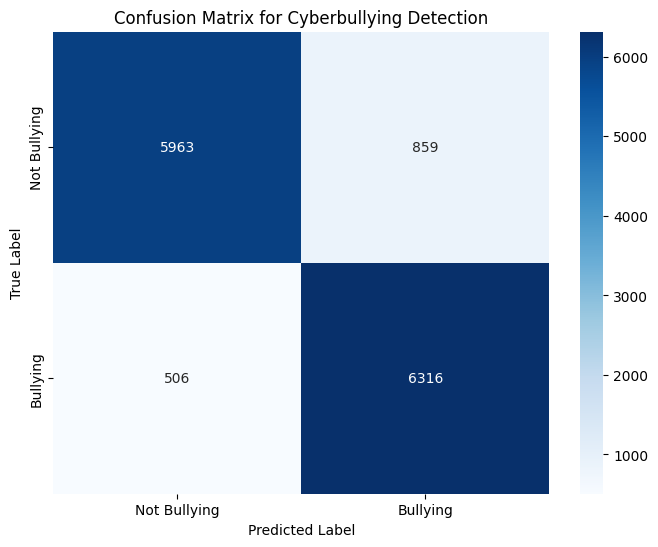

In [14]:
# Cell 7: Evaluate the model and visualize results
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("--- Evaluating model on the test set ---")

# --- Make Predictions ---
predictions = trainer.predict(tokenized_test_dataset)
predicted_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = tokenized_test_dataset['label']

# --- Calculate and Print Final Metrics ---
final_metrics = compute_metrics((predictions.predictions, true_labels))
print(f"\nFinal Test Metrics:")
print(f"  - Accuracy:  {final_metrics['accuracy']:.4f}")
print(f"  - F1-Score:  {final_metrics['f1']:.4f}")
print(f"  - Precision: {final_metrics['precision']:.4f}")
print(f"  - Recall:    {final_metrics['recall']:.4f}")

# --- Generate and Plot Confusion Matrix ---
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Bullying', 'Bullying'], 
            yticklabels=['Not Bullying', 'Bullying'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Cyberbullying Detection')
plt.show()
